# Conjugation: Bond Rotation in Butane

To understand the effect of conjugation it is useful to explore the conformational energy profile for rotating the central C-C bond in butane and butadiene. this notebook will present the profile for **butane**.

We can calculate the energy for different conformations of butane using programs that perform quantum mechanical calculations. I have no idea what is happening under the hood, but this python notebook will document my methods and then others can correct my errors easily while judging me harshly. I will be using the ***Psi4*** computational chemistry package. It is freely available as a *Python* module and so it is very convenient to use in a notebook like this one.

## Setting Up

First I am going to set up the calculation by setting the variables in the code block below. You will see that I choose the name of the job (`basename`: this will be used to name the log and result files) and an extra name to add to that name as I try multiple runs (`runname`). I also set up information for what angles to set for the bond rotation(`start_angle`, `end_angle`, and `step_size`). the most important data is the structural data. I must describe the positions of atoms for the calculation. I set a text block in a variable called `butane_template` to hold the structural info. The format does not matter, just know that the data describes the initial structure.  the `{phi}` placeholder will be replaced with the chosen bond angle in the calculations that follow.

If your interested, the structural data is presented as a z-matrix. this is a format that describes the positions of atoms relative to each other. the firest line states the charge and electronic state as 0 charge and a singlet electronic state (singlet means all electrons are paired). the following lines describe the atoms. the Z-matric copuld be describes as follows...

```
Atom #1 is carbon;
Atom #2 is carbon and it is 1.54 Angstroms from atom #1.
Atom #3 is carbon and it is 1.54 Angstroms from atom #2 and at an angle of 112 degrees from the 1,2 bond 
Atom #4 is carbon and it is 1.54 Angstroms from atom #3 and at an angle of 112 degrees from the 2,3 bond and at a torsional angle of {phi} from the plane defined by atoms 1,2 and 3.
Atom #h is hydrogen and it is 1.09 Angstroms from atom #1 and at an angle of 109.5 degrees from the 1,2 bond and at a torsional angle of {phi} from the plane defined by atoms 1,2 and 3.
etc.
```

We now have everything set up. We will need only to change this setup infromation when we switch to butadiene in the next notebook.

In [ ]:

basename = "butane_scan" # Base name for log files and output CSV file. This will be combined with the 'runname' variable to create unique file names for each run.
runname = "3" # You can change this to keep track of different runs with different settings. This will be used in the log file names and the output CSV file name.

method = "hf/6-31G*" # You can change this to use a different level of theory and basis set. For example, "mp2/6-31G*", "b3lyp/6-31G*", etc.

start_angle = 0 # Starting dihedral angle in degrees
end_angle = 180 # Ending dihedral angle in degrees
step_size = 10 # Step size for dihedral angle in degrees


# Define base butane geometry (Z-matrix for easy dihedral manipulation)
# I added 1 to all torsion angles to avoid symmetry locks in the structure. This is a common trick to break 
#    symmetry and allow the optimization to proceed without getting stuck in a high-symmetry point.
butane_template = """
0 1
C
C 1 1.54
C 2 1.54 1 112.0
C 3 1.54 2 112.0 1 {phi}
H 1 1.09 2 109.5 3 181.0
H 1 1.09 2 109.5 3 61.0
H 1 1.09 2 109.5 3 -61.0
H 2 1.09 3 109.5 1 181.0
H 2 1.09 3 109.5 1 61.0
H 3 1.09 4 109.5 2 181.0
H 3 1.09 4 109.5 2 61.0
H 4 1.09 3 109.5 2 -61.0
H 4 1.09 3 109.5 2 61.0
H 4 1.09 3 109.5 2 181.0
"""



## Running *Psi4*

In [ ]:
import psi4
import numpy as np
import pandas as pd
import sys
from contextlib import redirect_stdout
from contextlib import redirect_stderr
import time

# Set Psi4 options
psi4.core.set_output_file(f"{basename}_{runname}.log", False) # True: append logs; False: overwrite logs
psi4.set_memory('2 GB')
psi4.set_num_threads(4) # Adjust based on your CPU cores; 1 for single-threaded, more for parallel
psi4.set_options({
    'print': 1,         # 0 for no output, 1 for minimal output, 2 for detailed output. Needs to be set to 1 or greater for optking to work properly.
    'reference': 'rhf', # 'uhf', 'rhf', 'rohf'
    'scf_type': 'df',   # density fitting for faster SCF. Other options are 'pk' (default), 'direct', 'outofcore' and more
    'optking__frozen_dihedral': '1 2 3 4'
    })

# define message for header of each optimization run in the loop. This will be printed to the stderr file for each angle, so we can easily see where each optimization starts in the log.
dihedral_print_message = """

--------------------------------------------------
Starting optimization for dihedral angle: {phi:.1f} degrees
--------------------------------------------------

"""


# Define scan range (0 to 360 degrees)
angles = np.arange(start_angle, end_angle + step_size, step_size) # Generate array of dihedral angles from start to end with the specified step size
energies = []
molecules = []
wavefunctions = []

globalstart = time.time()
with open(f"{basename}_stderr_{runname}.txt", "w") as f: # These with statements redirect the standard error output (which is where Psi4 writes its logs) to a file called "stderr.txt". This allows us to capture the verbose output from Psi4 without cluttering the console.
    with redirect_stderr(f):

        # Loop over angles and perform calculations for butane at each angle
        for phi in angles:
            sys.stderr.write(dihedral_print_message.format(phi=phi)) # Print to a file for stderr. verbose output from Psi4 will be written to this file.

            print(f"Calculating for dihedral = {phi:.1f} deg")
        
            # Create molecule with current dihedral
            mol = psi4.geometry(butane_template.format(phi=phi))
            molecules.append(mol)
        
            # Compute energy (with structural optimization)
            start = time.time()

            ###############################
            # This is where Psi4 is used. This will use the structure established from 'butane_template' with the 
            #     angle 'phi' set to a value from the list 'angles'. The 'optimize' function will perform a geometry 
            #     optimization at the specified level of theory (SCF in this case) while keeping the specified 
            #     dihedral angle frozen. 'hf' is the level of theory (Hartree-Fock). You can change this to 'mp2', 
            #     'ccsd', 'b3lyp', etc. for more accurate calculations, but it will take longer.
            ###############################
            energy, wfn = psi4.optimize(method, molecule=mol, return_wfn=True)
            ###############################
            # End of Psi4 calculation. Everything else is just setup and timing. 
            ###############################

            energies.append(energy) # The final optimized energy from the calculation is stored in the 'energies' list.
            wavefunctions.append(wfn) # The wavefunction from the calculation is stored in the 'wavefunctions' list.

            end = time.time()
            print(f"Time for dihedral optimization {phi:.1f} deg: {end - start:.2f} seconds")

globalend = time.time()
print(f"Total time for scan: {globalend - globalstart:.2f} seconds")

# Get relative energies (kJ/mol)
energies_array = np.array(energies)                    # Convert list to numpy array for easier manipulation
energies_array = energies_array - energies_array.min() # Set minimum energy to zero
energies_array = energies_array * 627.509 * 4.184      # ConvertHartree to kJ/mol

# Print results
print("\nAngle (deg)   Energy (kJ/mol)")
for angle, energy in zip(angles, energies_array):
    print(f"{angle:8.1f}   {energy:12.4f}")

print("\nScan complete.")

# make dataframe from angles and energies
df = pd.DataFrame({
    'Dihedral Angle (deg)': angles,
    'Energy (kJ/mol)': energies_array
    })

# Save to CSV
df.to_csv(f"{basename}_{runname}.csv", index=False)

NameError: name 'basename' is not defined

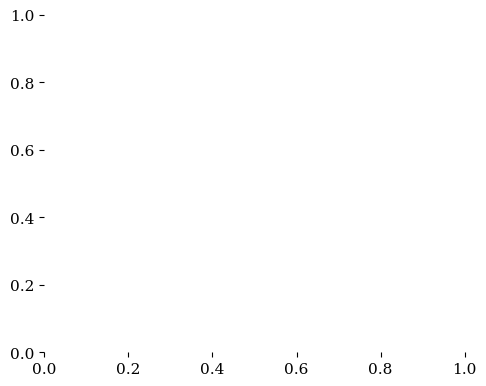

In [2]:


import matplotlib.pyplot as plt

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

ax.plot(df["Dihedral Angle (deg)"], df["Energy (kJ/mol)"], marker='o')
ax.set_xlabel("Dihedral Angle (deg)")
ax.set_ylabel(r"Energy $/\,kJ\; mol^{-1}$")
ax.set_title("Butane Rotation Profile")
#plt.grid()
plt.show()

